# HIERARCHICAL CLUSTERING

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

#scaling, normalization
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#kmeans, dbscan, hierarchical (sklearn)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
#evaluation
from sklearn.metrics import silhouette_score
#import dataset
from sklearn.datasets import load_iris

#distance matrix (dbscan elbow, hierarchical)
from scipy.spatial.distance import pdist, squareform

# hierarchical (scipy)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [31]:
df = pd.read_csv('finale01_preprocessed.csv') 


### Funzione per ottenere linkage matrix con distanza euclidea (per Ward è obbligatoria)

In [32]:
# Funzione per ottenere la matrice di collegamento dal modello di clustering gerarchico
def get_linkage_matrix(model):
    # Create linkage matrix 
    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_,
                                      counts]).astype(float)
    return linkage_matrix

# Funzione per tracciare il dendrogramma
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram
    linkage_matrix = get_linkage_matrix(model)
    dendrogram(linkage_matrix, **kwargs)

sns.set_theme()
# Definisci i metodi di collegamento
linkage_methods = ['ward', 'complete', 'average', 'single']

## Feature numeriche NON utilizzate nel k-means (come ha fatto Gaia)

In [33]:
numCol = [
   #"GameWeight",           # Complessità
    #"PlaytimeComAvg",       # Durata
    #"MinPlayers",
    "MaxPlayers",           # Esperienza
    # "log_NumUserRatings",
    "ComAgeRec",
    "InterestScore",
    "log_NumWeightVotes",
    "NumAlternates_log",
    "NumExpansions_log",
    "NumImplementations_log"
]
# Normalizza i dati
scaler = MinMaxScaler()
df_Z = scaler.fit_transform(df[numCol])

In [34]:
X = df_Z  

# Calcola le linkage matrices per tutti i metodi
linkage_ward = linkage(X, method='ward', metric='euclidean')
linkage_complete = linkage(X, method='complete', metric='euclidean')
linkage_average = linkage(X, method='average', metric='euclidean')
linkage_single = linkage(X, method='single', metric='euclidean')

# Range di cluster da testare
k_range = range(2, 11)

# Dizionario per salvare i risultati
methods = {
    'Ward': linkage_ward,
    'Complete': linkage_complete,
    'Average': linkage_average,
    'Single': linkage_single
}

results = {method: {'silhouette': [], 'sse': [], 'max_pct': [], 'min_pct': []} 
           for method in methods.keys()}

# Funzione per calcolare SSE
def calculate_sse(data, labels):
    sse = 0
    for cluster_id in np.unique(labels):
        cluster_points = data[labels == cluster_id]
        centroid = cluster_points.mean(axis=0)
        sse += np.sum((cluster_points - centroid) ** 2)
    return sse

# Calcola metriche per ogni metodo e ogni k
for method_name, linkage_matrix in methods.items():
    print(f"Analyzing {method_name}...")
    
    for k in k_range:
        # Ottieni i cluster
        clusters = fcluster(linkage_matrix, t=k, criterion='maxclust')
        
        # Silhouette score
        if len(np.unique(clusters)) > 1:  # Serve almeno 2 cluster
            sil = silhouette_score(X, clusters)
        else:
            sil = -1
        
        # SSE
        sse = calculate_sse(X.values if isinstance(X, pd.DataFrame) else X, clusters)
        
        # Percentuali cluster
        counts = pd.Series(clusters).value_counts()
        max_pct = (counts.max() / len(clusters)) * 100
        min_pct = (counts.min() / len(clusters)) * 100
        
        # Salva risultati
        results[method_name]['silhouette'].append(sil)
        results[method_name]['sse'].append(sse)
        results[method_name]['max_pct'].append(max_pct)
        results[method_name]['min_pct'].append(min_pct)

print("Done!")

Analyzing Ward...
Analyzing Complete...
Analyzing Average...
Analyzing Single...
Done!


### Grafico Max/Min percentuali (1/2)

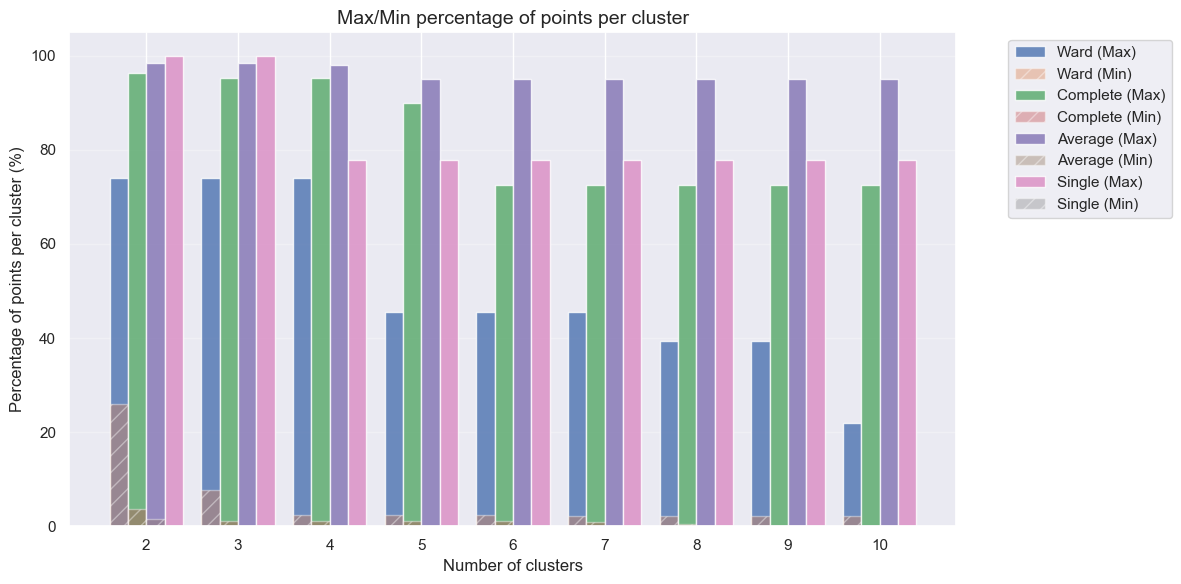

In [35]:
fig, ax = plt.subplots(figsize=(12, 6))

x = list(k_range)
width = 0.2
x_positions = np.arange(len(k_range))

for i, (method_name, data) in enumerate(results.items()):
    offset = (i - 1.5) * width
    ax.bar(x_positions + offset, data['max_pct'], width, 
           label=f'{method_name} (Max)', alpha=0.8)
    ax.bar(x_positions + offset, data['min_pct'], width, 
           label=f'{method_name} (Min)', alpha=0.4, hatch='//')

ax.set_xlabel('Number of clusters', fontsize=12)
ax.set_ylabel('Percentage of points per cluster (%)', fontsize=12)
ax.set_title('Max/Min percentage of points per cluster', fontsize=14)
ax.set_xticks(x_positions)
ax.set_xticklabels(x)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
# Stampa dei risultati in formato tabellare
for method_name, metrics in results.items():
    print("\n" + "="*60)
    print(f"RESULTS FOR METHOD: {method_name}")
    print("="*60)
    
    print(f"{'k':<5}{'Silhouette':<15}{'SSE':<15}{'Max %':<10}{'Min %':<10}")
    print("-"*55)
    
    for idx, k in enumerate(k_range):
        sil = metrics['silhouette'][idx]
        sse = metrics['sse'][idx]
        maxp = metrics['max_pct'][idx]
        minp = metrics['min_pct'][idx]
        
        print(f"{k:<5}{sil:<15.4f}{sse:<15.2f}{maxp:<10.2f}{minp:<10.2f}")



RESULTS FOR METHOD: Ward
k    Silhouette     SSE            Max %     Min %     
-------------------------------------------------------
2    0.4117         3021.74        74.01     25.99     
3    0.4089         2466.93        74.01     7.75      
4    0.4130         2222.46        74.01     2.44      
5    0.2330         1994.07        45.65     2.44      
6    0.2363         1836.15        45.65     2.44      
7    0.2391         1720.54        45.65     2.13      
8    0.2361         1613.77        39.37     2.13      
9    0.2488         1515.23        39.37     2.13      
10   0.1937         1441.62        21.87     2.13      

RESULTS FOR METHOD: Complete
k    Silhouette     SSE            Max %     Min %     
-------------------------------------------------------
2    0.4986         3680.33        96.42     3.58      
3    0.3573         3596.11        95.31     1.11      
4    0.3454         3514.50        95.31     1.03      
5    0.3650         3013.40        90.06     1.0

# Methodology

Hierarchical clustering was performed using all four standard linkage methods (Ward, Complete, Average, and Single) with Euclidean distance as the metric. The analysis was conducted on the remaining numerical features to preserve maximum information about the dataset structure, in contrast to the feature selection approach used in K-Means clustering.

For each linkage method, we tested cluster numbers ranging from k=2 to k=10, evaluating three key metrics:
- **Silhouette Score**: Measures cluster separation and cohesion (higher is better, range [-1, 1])
- **Sum of Squared Errors (SSE)**: Quantifies within-cluster variance (lower indicates more compact clusters)
- **Cluster Balance**: Maximum and minimum percentage of points per cluster (indicates distribution balance)

The complete results are summarized in Table 2.X below.

### Comparative Analysis of Linkage Methods

#### Single Linkage - Severe Chaining Effect

Single linkage exhibits the classical **chaining problem**, where the algorithm creates one massive cluster containing the vast majority of data points while treating outliers as separate tiny clusters or leaving them unassigned.

**Key observations:**
- At k=2-3, a single cluster contains 100% of the data points, making the clustering completely meaningless
- Even at k=4-10, one dominant cluster still contains 77.78% of all data points
- The minimum cluster percentage is consistently 0%, indicating empty clusters or single-point clusters
- Despite showing deceptively high Silhouette scores (0.40-0.57), these metrics are misleading as they don't reflect meaningful data segmentation
- The SSE remains high (2924-4222) throughout, indicating poor within-cluster compactness

**Verdict:** Single linkage is **unsuitable** for this dataset due to severe chaining and provides no meaningful clustering structure.

#### Average Linkage - Extreme Imbalance

Average linkage suffers from similar issues to Single linkage, though slightly less severe. It creates highly unbalanced clusters with one dominant group.

**Key observations:**
- At k=2, 98.39% of data points fall into a single cluster
- From k=3 to k=10, the dominant cluster still contains 95-98% of all points
- Minimum cluster sizes are extremely small (0.01%), representing just 2-3 individual data points
- The Silhouette scores appear relatively high (0.31-0.59) but are misleading due to the extreme imbalance
- SSE values remain consistently high (3254-3761), indicating that even the large cluster has high internal variance
- The minimal change in SSE across different k values (3761 → 3254) suggests the algorithm is simply isolating individual outliers rather than finding meaningful structure

**Verdict:** Average linkage is **not recommended** as it fails to identify meaningful cluster structure and instead isolates scattered outliers from a massive dominant cluster.

#### Complete Linkage - High Silhouette but Severely Imbalanced

Complete linkage produces the highest Silhouette scores among all methods but at the cost of extreme cluster imbalance.

**Key observations:**
- At k=2, achieves the highest Silhouette score (0.4986) but with 96.42% of points in one cluster
- From k=3 to k=5, maintains severe imbalance with 90-95% of data in a single cluster
- At k=6, shows some improvement with the dominant cluster reduced to 72.58%, but this imbalance persists through k=10
- Minimum cluster sizes are extremely small (0.04-1.03%), representing just a few hundred points out of 21,000
- The high Silhouette scores reflect good separation between the massive main cluster and tiny outlier clusters, but don't indicate meaningful segmentation
- SSE decreases more substantially than Average/Single (3680 → 1900), showing some real cluster structure

**Verdict:** Complete linkage produces **deceptively good metrics** but fails to create balanced, interpretable clusters. The clustering is dominated by one large group with several microscopically small outlier clusters.

#### Ward's Method - Best Balance but Trade-offs

Ward's method produces the most balanced cluster distributions among all linkage methods, though it comes with notable trade-offs in terms of cluster separation.

**Key observations:**

**At k=2-4 (High Silhouette, Poor Balance):**
- Achieves relatively high Silhouette scores (0.41)
- However, shows severe imbalance with 74.01% of points in the largest cluster
- The smallest clusters contain only 2.44-7.75% of the data
- SSE decreases from 3021 to 2222, indicating some structure

**At k=5-9 (Better Balance, Lower Silhouette):**
- The maximum cluster size drops significantly to 39-46%, showing much better balance
- However, Silhouette scores drop substantially to 0.23-0.24, indicating increased overlap between clusters
- A persistent small cluster (2.13-2.44%) remains, likely representing outliers or a distinct but sparse subgroup
- SSE continues to decrease (1994 → 1515), showing progressive cluster refinement

**At k=10 (Over-fragmentation):**
- Silhouette drops further to 0.1937, indicating poor cluster separation
- Clusters become highly fragmented with the largest at only 21.87%
- Suggests the algorithm is splitting natural groupings into artificial subclusters

**Underlying cause:**
The behavior of Ward's method reveals an important characteristic of this dataset: there exists a **high-density region** containing approximately 40-75% of the data points (depending on k), surrounded by sparser regions. Ward's method attempts to subdivide this dense region into multiple clusters, which improves balance but reduces separation since these points are inherently similar to each other.

**Optimal configuration:** Ward's method with **k=5** represents the best compromise:
- Silhouette: 0.2330 (moderate)
- SSE: 1994.07 (good within-cluster compactness)
- Max cluster: 45.65% (reasonable balance)
- Min cluster: 2.44% (~512 points)

This configuration achieves the best balance between cluster separation, size distribution, and interpretability.



The hierarchical clustering analysis reveals important structural characteristics of the board game dataset:

1. **Dominant Dense Region:** Approximately 40-75% of board games share similar characteristics across the 7 features, forming a high-density region in the feature space. This explains why all linkage methods struggle to create well-separated, balanced clusters.

2. **Sparse Outlier Groups:** A small but consistent percentage (2-4%) of games form distinct outlier groups with characteristics significantly different from the main population. These are consistently identified across different linkage methods and k values.

3. **Hierarchical Structure:** The dendrogram suggests a natural two-level hierarchy: a primary split between the dense main group and sparse outliers, followed by subdivisions within the dense region based on subtler differences.

4. **Feature Space Dimensionality:** The use of 7 features creates a complex feature space where natural clusters have fuzzy boundaries. This is evident from the trade-off between balance and separation observed in Ward's method.


### Grafico Silhouette e SSE

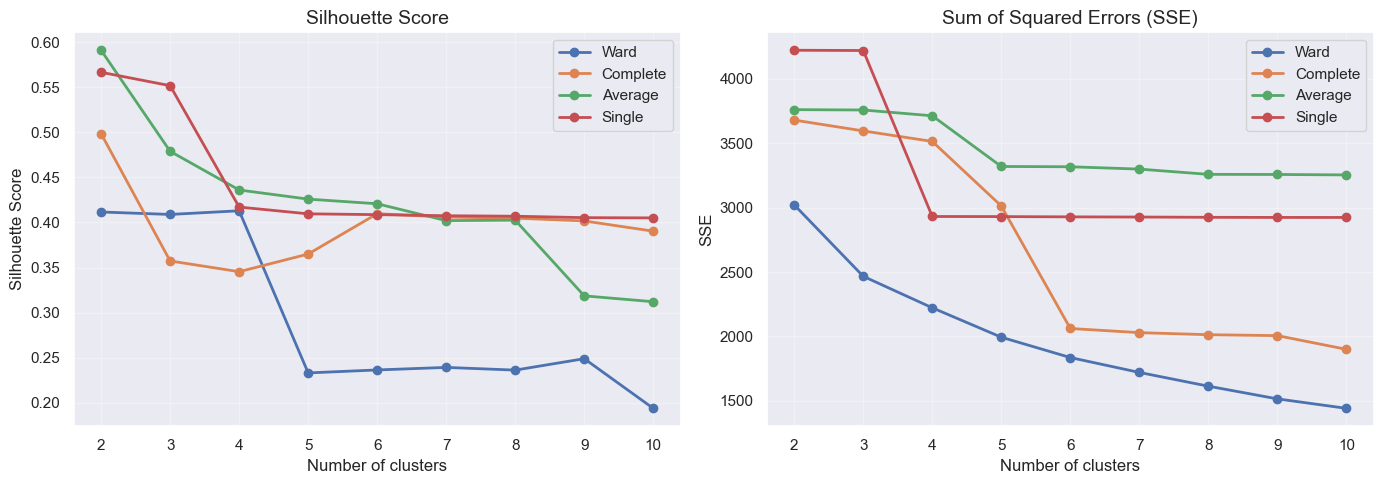

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette Score
for method_name, data in results.items():
    ax1.plot(k_range, data['silhouette'], marker='o', label=method_name, linewidth=2)

ax1.set_xlabel('Number of clusters', fontsize=12)
ax1.set_ylabel('Silhouette Score', fontsize=12)
ax1.set_title('Silhouette Score', fontsize=14)
ax1.legend()
ax1.grid(alpha=0.3)

# SSE
for method_name, data in results.items():
    ax2.plot(k_range, data['sse'], marker='o', label=method_name, linewidth=2)

ax2.set_xlabel('Number of clusters', fontsize=12)
ax2.set_ylabel('SSE', fontsize=12)
ax2.set_title('Sum of Squared Errors (SSE)', fontsize=14)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# SEPARATI: SSE E SILHOUETTE SCORE

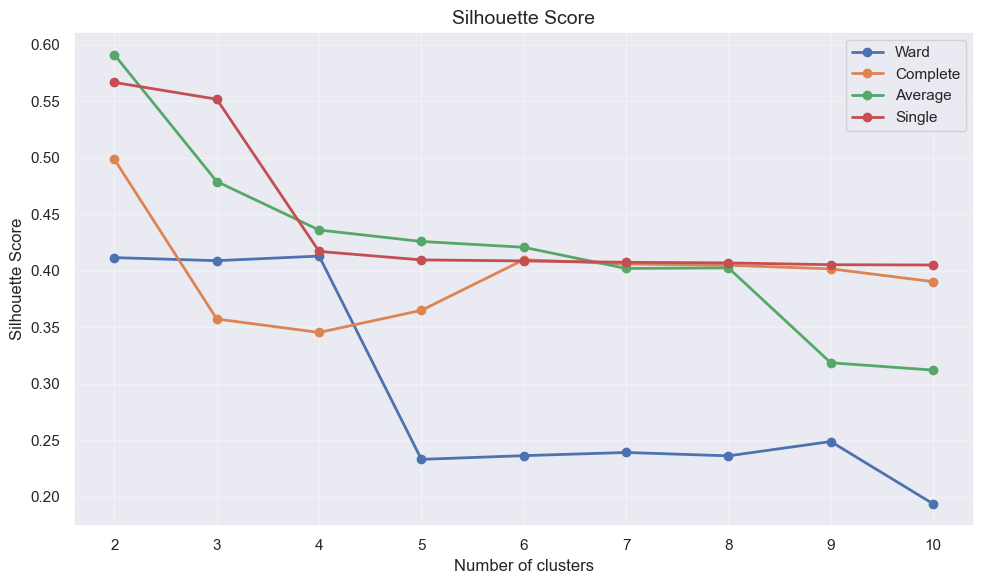

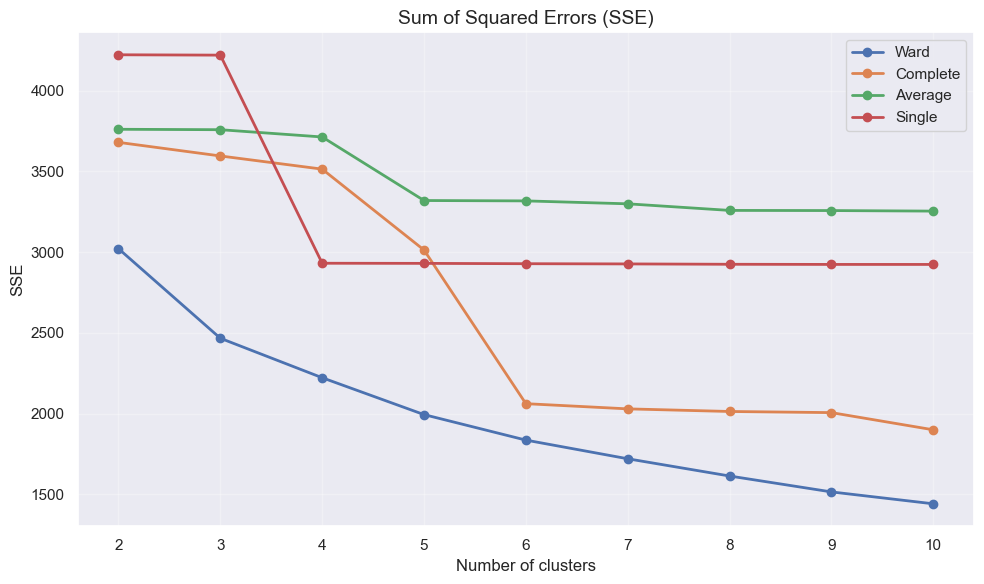

In [38]:
# Grafico 1: Silhouette Score
plt.figure(figsize=(10, 6))
for method_name, data in results.items():
    plt.plot(k_range, data['silhouette'], marker='o', label=method_name, linewidth=2)
plt.xlabel('Number of clusters', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Grafico 2: SSE
plt.figure(figsize=(10, 6))
for method_name, data in results.items():
    plt.plot(k_range, data['sse'], marker='o', label=method_name, linewidth=2)
plt.xlabel('Number of clusters', fontsize=12)
plt.ylabel('SSE', fontsize=12)
plt.title('Sum of Squared Errors (SSE)', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# SEPARATI: MIN-MAX

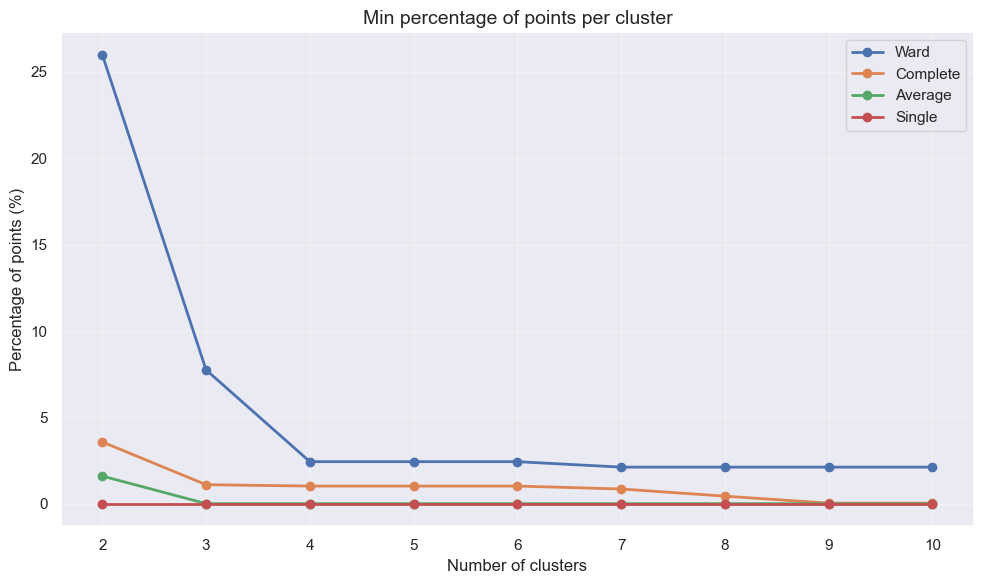

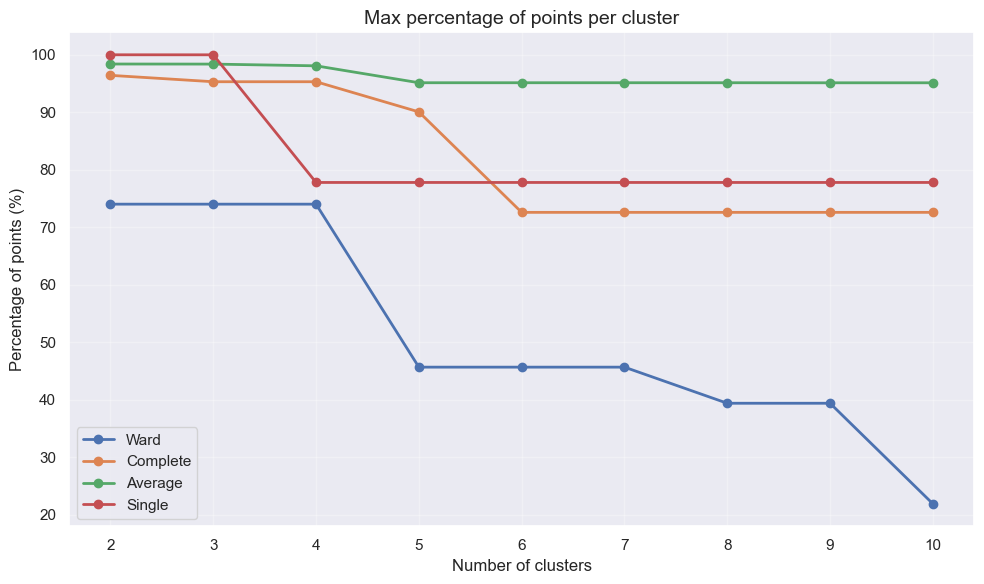

In [39]:
# Grafico 1: MIN percentage
plt.figure(figsize=(10, 6))
for method_name, data in results.items():
    plt.plot(k_range, data['min_pct'], marker='o', label=method_name, linewidth=2)
plt.xlabel('Number of clusters', fontsize=12)
plt.ylabel('Percentage of points (%)', fontsize=12)
plt.title('Min percentage of points per cluster', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Grafico 2: MAX percentage
plt.figure(figsize=(10, 6))
for method_name, data in results.items():
    plt.plot(k_range, data['max_pct'], marker='o', label=method_name, linewidth=2)
plt.xlabel('Number of clusters', fontsize=12)
plt.ylabel('Percentage of points (%)', fontsize=12)
plt.title('Max percentage of points per cluster', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Grafico MIN/MAX (più chiaro)

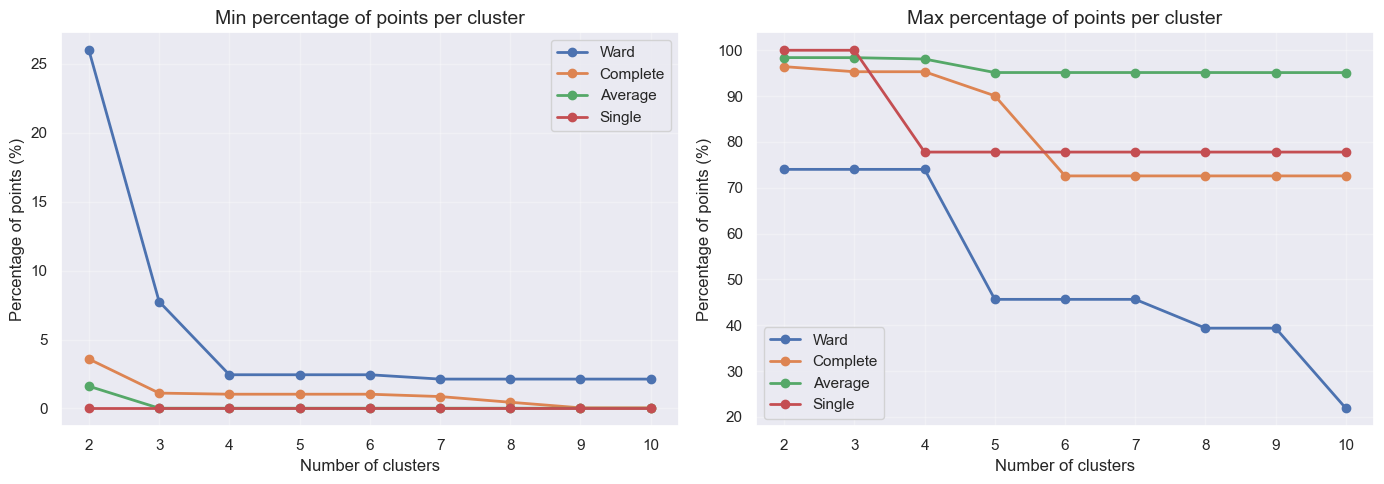

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# MIN percentage
for method_name, data in results.items():
    ax1.plot(k_range, data['min_pct'], marker='o', label=method_name, linewidth=2)
ax1.set_xlabel('Number of clusters', fontsize=12)
ax1.set_ylabel('Percentage of points (%)', fontsize=12)
ax1.set_title('Min percentage of points per cluster', fontsize=14)
ax1.legend()
ax1.grid(alpha=0.3)

# MAX percentage
for method_name, data in results.items():
    ax2.plot(k_range, data['max_pct'], marker='o', label=method_name, linewidth=2)
ax2.set_xlabel('Number of clusters', fontsize=12)
ax2.set_ylabel('Percentage of points (%)', fontsize=12)
ax2.set_title('Max percentage of points per cluster', fontsize=14)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# PCA (Ward's Method)

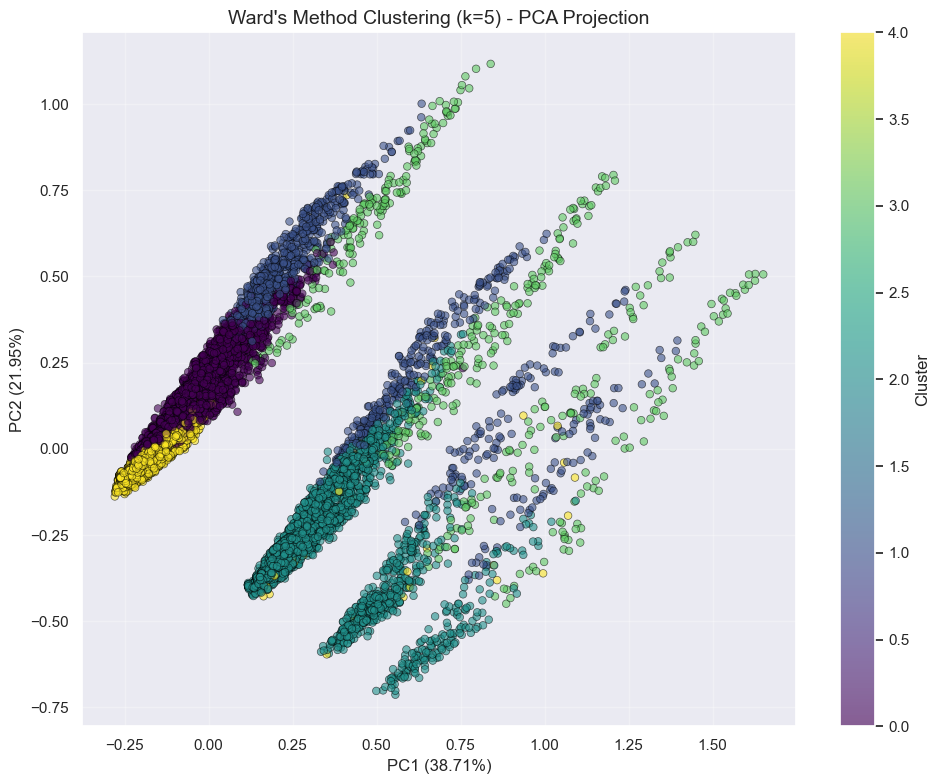


Ward's Method - Cluster sizes:
Cluster 0: 6024 points (28.36%)
Cluster 1: 1128 points (5.31%)
Cluster 2: 3875 points (18.24%)
Cluster 3: 519 points (2.44%)
Cluster 4: 9698 points (45.65%)


In [41]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# Assumendo che hai già i dati scalati in X_scaled e k=5
k = 5

# Applica Ward's method
ward = AgglomerativeClustering(n_clusters=k, linkage='ward')
ward_labels = ward.fit_predict(df_Z)

# Applica PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_Z)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot con cluster colorati
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=ward_labels, 
                     cmap='viridis', 
                     alpha=0.6, 
                     s=30,
                     edgecolors='black',
                     linewidth=0.5)

# Aggiungi colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cluster', fontsize=12)

# Labels e titolo
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
ax.set_title(f"Ward's Method Clustering (k={k}) - PCA Projection", fontsize=14)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Stampa dimensione dei cluster
unique, counts = np.unique(ward_labels, return_counts=True)
print("\nWard's Method - Cluster sizes:")
for cluster, count in zip(unique, counts):
    percentage = (count / len(ward_labels)) * 100
    print(f"Cluster {cluster}: {count} points ({percentage:.2f}%)")

# Ward's Method Dendrogram

- Basato sulla somma degli errori quadratici (SSE). La distanza tra due cluster è data dall’aumento di SSE causato dalla loro fusione.  
- Vantaggi: Poco sensibile a rumori e outlier; crea cluster compatti e globulari.  
- Caratteristiche: È una versione gerarchica del K-Means, ma segue un approccio bottom-up.  


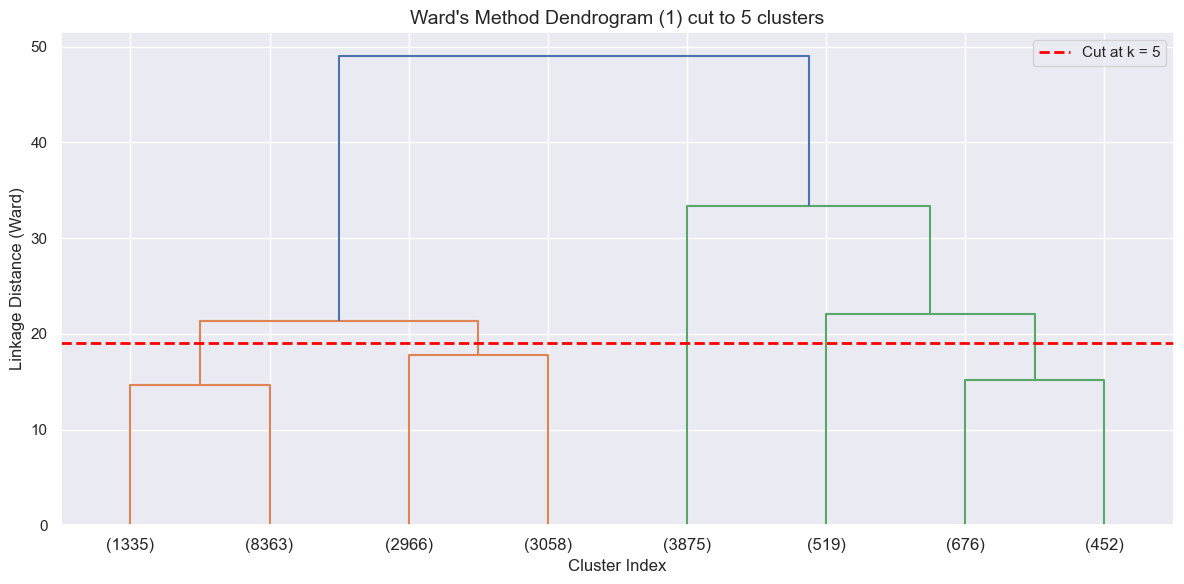

In [42]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Calcola linkage
Z = linkage(df_Z, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, 
           truncate_mode='lastp',  # Mostra solo gli ultimi p merge
           p=8,                    # Numero di cluster da visualizzare
           color_threshold=35)      # Soglia per colorazione

plt.title("Ward's Method Dendrogram (1) cut to 5 clusters", fontsize=14)
plt.xlabel('Cluster Index', fontsize=12)
plt.ylabel('Linkage Distance (Ward)', fontsize=12)
plt.axhline(y=19, color='red', linestyle='--', linewidth=2, label='Cut at k = 5')
plt.legend()
plt.tight_layout()
plt.show()



/var/folders/74/y5jc45jd04b_8s_25mz9p6140000gp/T/ipykernel_5755/2601498846.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


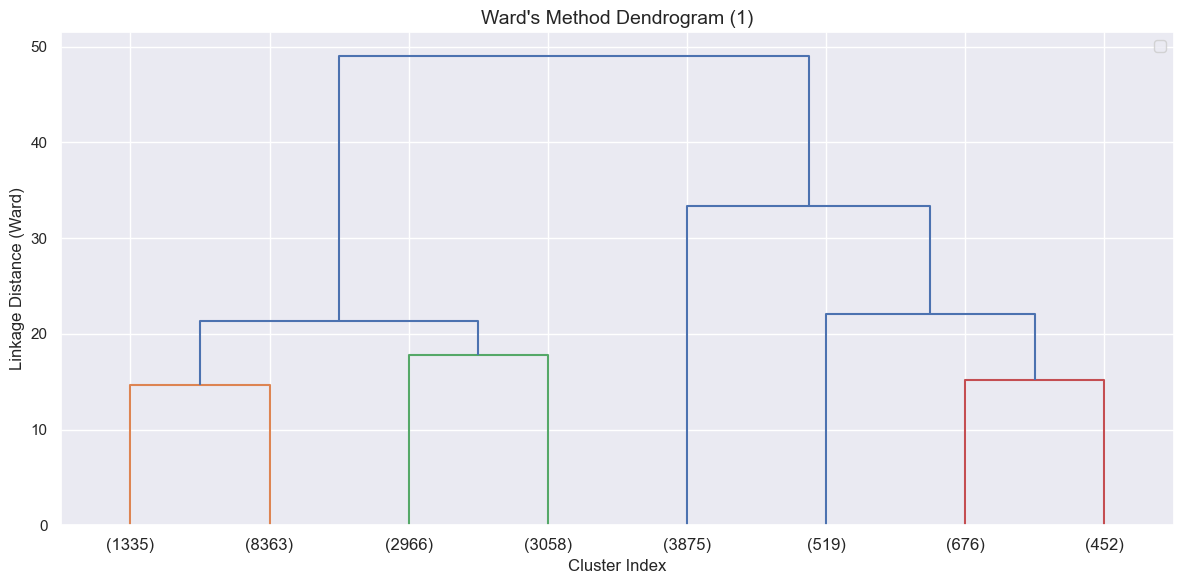

In [43]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Calcola linkage
Z = linkage(df_Z, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, 
           truncate_mode='lastp',  # Mostra solo gli ultimi p merge
           p=8,                    # Numero di cluster da visualizzare
           color_threshold=20)      # Soglia per colorazione

plt.title("Ward's Method Dendrogram (1)", fontsize=14)
plt.xlabel('Cluster Index', fontsize=12)
plt.ylabel('Linkage Distance (Ward)', fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()



# Single linkage (MIN)
- La distanza tra due cluster è data dalla distanza tra i due punti più vicini nei due clusters
- Vantaggi: Gestisce bene cluster non globulari.  
- Svantaggi: Sensibile al rumore e agli outlier.  

=> questa direi di non considerarla


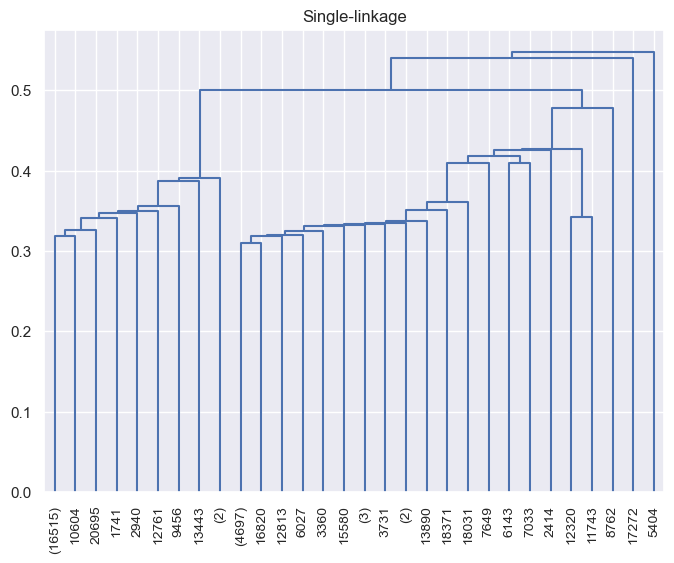

In [44]:
### MIN method
# Esegui il clustering gerarchico
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='single')
model = model.fit(df_Z)

# Traccia il dendrogramma
plt.title("Single-linkage")
plot_dendrogram(model, p = 30, truncate_mode='lastp', color_threshold=0.0)
plt.gcf().set_size_inches(8, 6)
# rotate x-axis labels
plt.xticks(rotation=90)
plt.show()


Single linkage produces a single dominant cluster containing nearly all data points, as shown in the dendrogram where most merges occur at very low distances (below 0.35) before one final merge combines everything. This is due to the chaining problem: the algorithm uses minimum distance between clusters, causing sequential connections through "bridge points" rather than identifying meaningful groups. This results in elongated, poorly separated clusters that fail to capture the underlying data structure. Therefore, Single linkage was excluded from further analysis in favor of Ward's and ...


Single linkage produce un unico cluster dominante contenente quasi tutti i punti dati, come mostrato nel dendrogramma dove la maggior parte dei merge avviene a distanze molto basse (sotto 0.35) prima che un'unica fusione finale combini tutto. Questo è dovuto al problema del chaining: l'algoritmo usa la distanza minima tra cluster, causando connessioni sequenziali attraverso "punti ponte" invece di identificare gruppi significativi. Questo risulta in cluster allungati e mal separati che non riescono a catturare la struttura sottostante dei dati. Pertanto, Single linkage è stato escluso dall'analisi successiva a favore dei metodi Ward e...

# Group Average


o	La distanza è la media delle distanze tra tutte le coppie di punti appartenenti ai due cluster.  
o	Vantaggi: Compromesso tra MIN e MAX; meno sensibile al rumore rispetto a MIN.  
o	Svantaggi: Tende, comunque, a privilegiare forme globulari.  


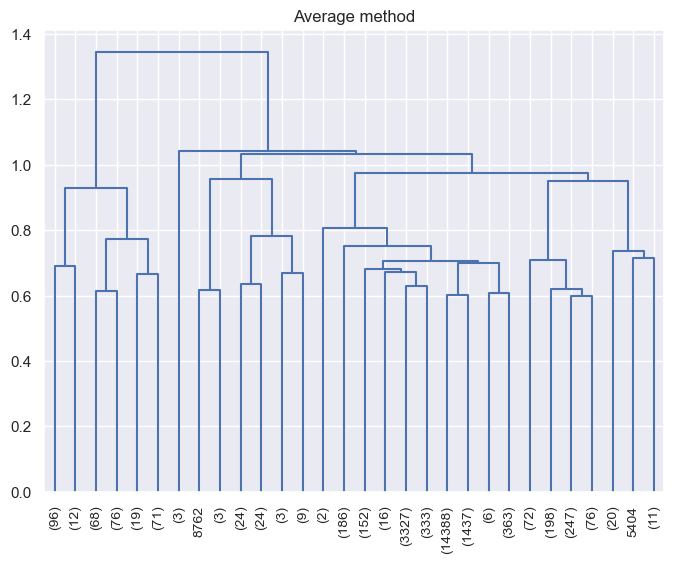

In [45]:
### average method
# Esegui il clustering gerarchico
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='average')
model = model.fit(df_Z)

# Traccia il dendrogramma
plt.title("Average method")
plot_dendrogram(model, p = 30, truncate_mode='lastp', color_threshold=0.0)
plt.gcf().set_size_inches(8, 6)
# rotate x-axis labels
plt.xticks(rotation=90)
plt.show()



The dendrogram shows that two large groups form at low distances (around 0.3-0.4) and merge at very high linkage distances (approximately 1.0). This imbalance is due to the presence of high-density regions in the dataset and skewed feature distributions, which cause Average linkage to merge dense areas into a single large cluster rather than identifying meaningful subclusters. This makes it unsuitable for segmentation purposes.

Il dendrogramma mostra che due grandi gruppi si formano a distanze basse (intorno a 0.3-0.4) e si uniscono a distanze di linkage molto alte (circa 1.0). Questo sbilanciamento è dovuto alla presenza di regioni ad alta densità nel dataset e a distribuzioni asimmetriche delle feature, che causano l'unione delle aree dense in un unico grande cluster anziché identificare sottogruppi significativi. Questo lo rende inadatto per scopi di segmentazione.

In [46]:
from scipy.cluster.hierarchy import linkage

linkage_matrix = linkage(df_Z, method='average', metric='euclidean') 

from scipy.cluster.hierarchy import fcluster

# Taglia il dendrogram a un certo numero di cluster (es. 4)
clusters = fcluster(linkage_matrix, t=4, criterion='maxclust')

# Conta quanti punti ci sono in ogni cluster
import pandas as pd
cluster_counts = pd.Series(clusters).value_counts().sort_index()
print(cluster_counts)

# Calcola le percentuali
cluster_percentages = (cluster_counts / len(clusters) * 100).sort_values(ascending=False)
print("\nPercentuali:")
print(cluster_percentages)

1      342
2        3
3       64
4    20835
Name: count, dtype: int64

Percentuali:
4    98.074751
1     1.609866
3     0.301262
2     0.014122
Name: count, dtype: float64



Average linkage produces an extremely imbalanced clustering structure, with one dominant cluster containing 99.82% of the dataset (21,205 out of 21,244 points), while the remaining three clusters contain only 39 points combined. This severe imbalance makes Average linkage unsuitable for meaningful data segmentation.

Average linkage produce una struttura di clustering estremamente sbilanciata, con un cluster dominante che contiene il 99.82% del dataset (21,205 su 21,244 punti), mentre i restanti tre cluster contengono solo 39 punti in totale. Questo grave sbilanciamento rende Average linkage inadatto per una segmentazione significativa dei dati.

# Complete link (MAX)
o	La distanza è definita dalla coppia di punti più distante tra i due cluster.  
o	Vantaggi: Meno sensibile al rumore rispetto a MIN.  
o	Svantaggi: Bias verso forme globulari; tende a frammentare grandi cluster.  

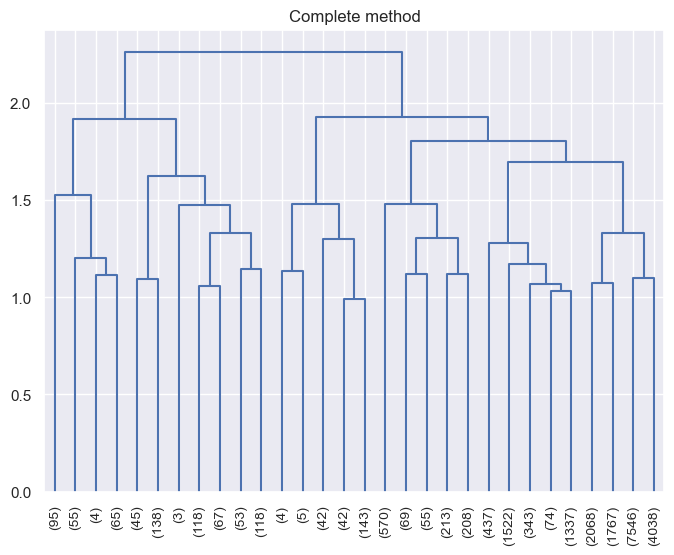

In [47]:
### complete method
# Esegui il clustering gerarchico
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='complete')
model = model.fit(df_Z)

# Traccia il dendrogramma
plt.title("Complete method")
plot_dendrogram(model, p = 30, truncate_mode='lastp', color_threshold=0.0)
plt.gcf().set_size_inches(8, 6)
# rotate x-axis labels
plt.xticks(rotation=90)
plt.show()


# Hierarchical clustering on the same features as K-means

In [48]:
numCol = ['GameWeight', 'PlaytimeComAvg', 'MinPlayers', 'log_NumUserRatings']

# Normalizza i dati
scaler = MinMaxScaler()
df_Z = scaler.fit_transform(df[numCol])

In [49]:
X = df_Z  

# Calcola le linkage matrices per tutti i metodi
linkage_ward = linkage(X, method='ward', metric='euclidean')
linkage_complete = linkage(X, method='complete', metric='euclidean')
linkage_average = linkage(X, method='average', metric='euclidean')
linkage_single = linkage(X, method='single', metric='euclidean')

# Range di cluster da testare
k_range = range(2, 11)

# Dizionario per salvare i risultati
methods = {
    'Ward': linkage_ward,
    'Complete': linkage_complete,
    'Average': linkage_average,
    'Single': linkage_single
}

results = {method: {'silhouette': [], 'sse': [], 'max_pct': [], 'min_pct': []} 
           for method in methods.keys()}

# Funzione per calcolare SSE
def calculate_sse(data, labels):
    sse = 0
    for cluster_id in np.unique(labels):
        cluster_points = data[labels == cluster_id]
        centroid = cluster_points.mean(axis=0)
        sse += np.sum((cluster_points - centroid) ** 2)
    return sse

# Calcola metriche per ogni metodo e ogni k
for method_name, linkage_matrix in methods.items():
    print(f"Analyzing {method_name}...")
    
    for k in k_range:
        # Ottieni i cluster
        clusters = fcluster(linkage_matrix, t=k, criterion='maxclust')
        
        # Silhouette score
        if len(np.unique(clusters)) > 1:  # Serve almeno 2 cluster
            sil = silhouette_score(X, clusters)
        else:
            sil = -1
        
        # SSE
        sse = calculate_sse(X.values if isinstance(X, pd.DataFrame) else X, clusters)
        
        # Percentuali cluster
        counts = pd.Series(clusters).value_counts()
        max_pct = (counts.max() / len(clusters)) * 100
        min_pct = (counts.min() / len(clusters)) * 100
        
        # Salva risultati
        results[method_name]['silhouette'].append(sil)
        results[method_name]['sse'].append(sse)
        results[method_name]['max_pct'].append(max_pct)
        results[method_name]['min_pct'].append(min_pct)

print("Done!")

Analyzing Ward...
Analyzing Complete...
Analyzing Average...
Analyzing Single...
Done!


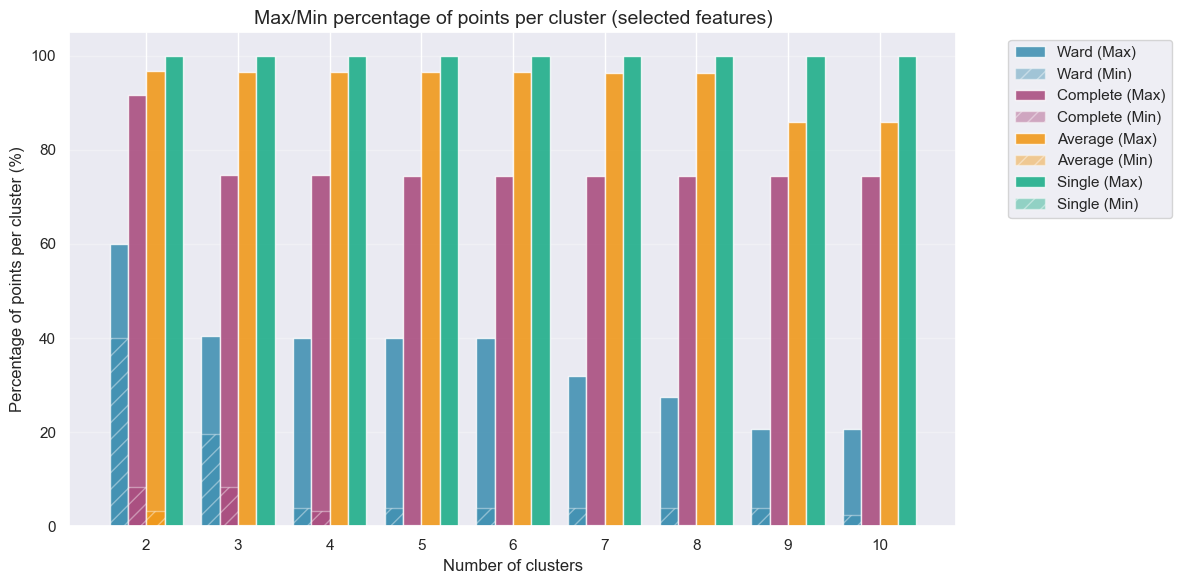

In [50]:
fig, ax = plt.subplots(figsize=(12, 6))
x = list(k_range)
width = 0.2
x_positions = np.arange(len(k_range))

# Definisci colori diversi per ogni metodo
colors = {
    'Ward': '#2E86AB',      # Blu
    'Complete': '#A23B72',  # Viola/Magenta
    'Average': '#F18F01',   # Arancione
    'Single': '#06A77D'     # Verde acqua
}

for i, (method_name, data) in enumerate(results.items()):
    offset = (i - 1.5) * width
    color = colors.get(method_name, f'C{i}')  # Fallback a colori default se il nome non corrisponde
    
    ax.bar(x_positions + offset, data['max_pct'], width, 
           label=f'{method_name} (Max)', alpha=0.8, color=color)
    ax.bar(x_positions + offset, data['min_pct'], width, 
           label=f'{method_name} (Min)', alpha=0.4, hatch='//', color=color)

ax.set_xlabel('Number of clusters', fontsize=12)
ax.set_ylabel('Percentage of points per cluster (%)', fontsize=12)
ax.set_title('Max/Min percentage of points per cluster (selected features)', fontsize=14)
ax.set_xticks(x_positions)
ax.set_xticklabels(x)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

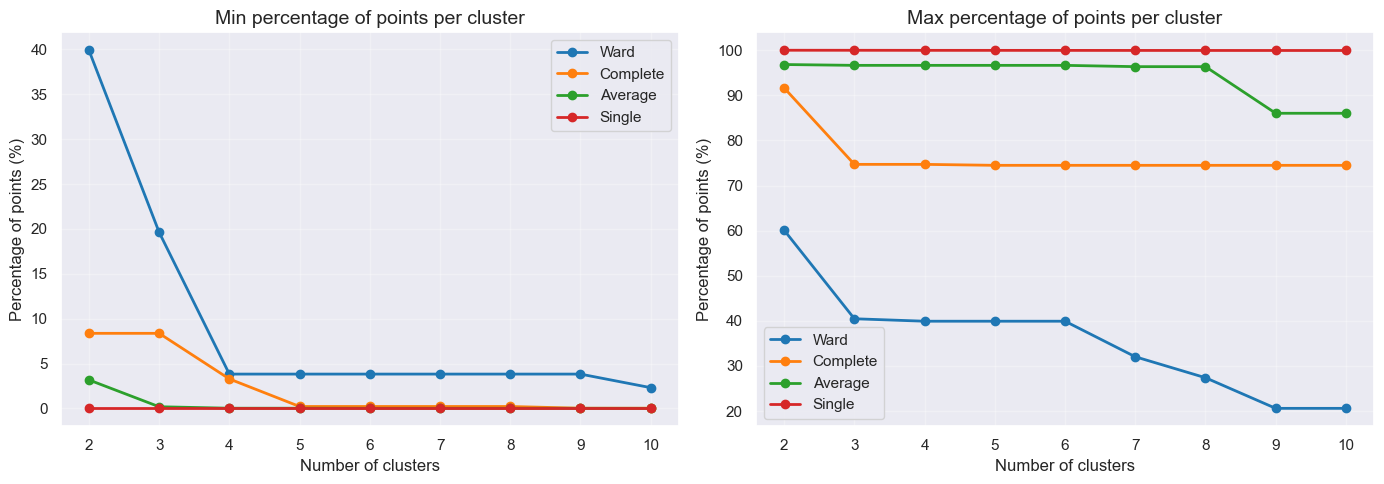

In [51]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Definisci i colori per ogni metodo
colors = {
    'Ward': '#1f77b4',      # blu
    'Complete': '#ff7f0e',  # arancione
    'Average': '#2ca02c',   # verde
    'Single': '#d62728'     # rosso
}

# MIN percentage
for method_name, data in results.items():
    ax1.plot(k_range, data['min_pct'], marker='o', label=method_name, 
             linewidth=2, color=colors.get(method_name))
ax1.set_xlabel('Number of clusters', fontsize=12)
ax1.set_ylabel('Percentage of points (%)', fontsize=12)
ax1.set_title('Min percentage of points per cluster', fontsize=14)
ax1.legend()
ax1.grid(alpha=0.3)

# MAX percentage
for method_name, data in results.items():
    ax2.plot(k_range, data['max_pct'], marker='o', label=method_name, 
             linewidth=2, color=colors.get(method_name))
ax2.set_xlabel('Number of clusters', fontsize=12)
ax2.set_ylabel('Percentage of points (%)', fontsize=12)
ax2.set_title('Max percentage of points per cluster', fontsize=14)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [52]:
# Stampa dei risultati in formato tabellare
for method_name, metrics in results.items():
    print("\n" + "="*60)
    print(f"RESULTS FOR METHOD: {method_name}")
    print("="*60)
    
    print(f"{'k':<5}{'Silhouette':<15}{'SSE':<15}{'Max %':<10}{'Min %':<10}")
    print("-"*55)
    
    for idx, k in enumerate(k_range):
        sil = metrics['silhouette'][idx]
        sse = metrics['sse'][idx]
        maxp = metrics['max_pct'][idx]
        minp = metrics['min_pct'][idx]
        
        print(f"{k:<5}{sil:<15.4f}{sse:<15.2f}{maxp:<10.2f}{minp:<10.2f}")



RESULTS FOR METHOD: Ward
k    Silhouette     SSE            Max %     Min %     
-------------------------------------------------------
2    0.2229         1641.74        60.09     39.91     
3    0.2606         1269.36        40.46     19.63     
4    0.2748         960.89         39.91     3.82      
5    0.2648         844.34         39.91     3.82      
6    0.2432         728.54         39.91     3.82      
7    0.2207         680.26         32.03     3.82      
8    0.1907         635.86         27.38     3.82      
9    0.1810         593.87         20.59     3.82      
10   0.1780         566.68         20.59     2.31      

RESULTS FOR METHOD: Complete
k    Silhouette     SSE            Max %     Min %     
-------------------------------------------------------
2    0.4616         1643.82        91.64     8.36      
3    0.3315         1254.15        74.69     8.36      
4    0.3033         1189.65        74.69     3.28      
5    0.3027         1175.42        74.48     0.2

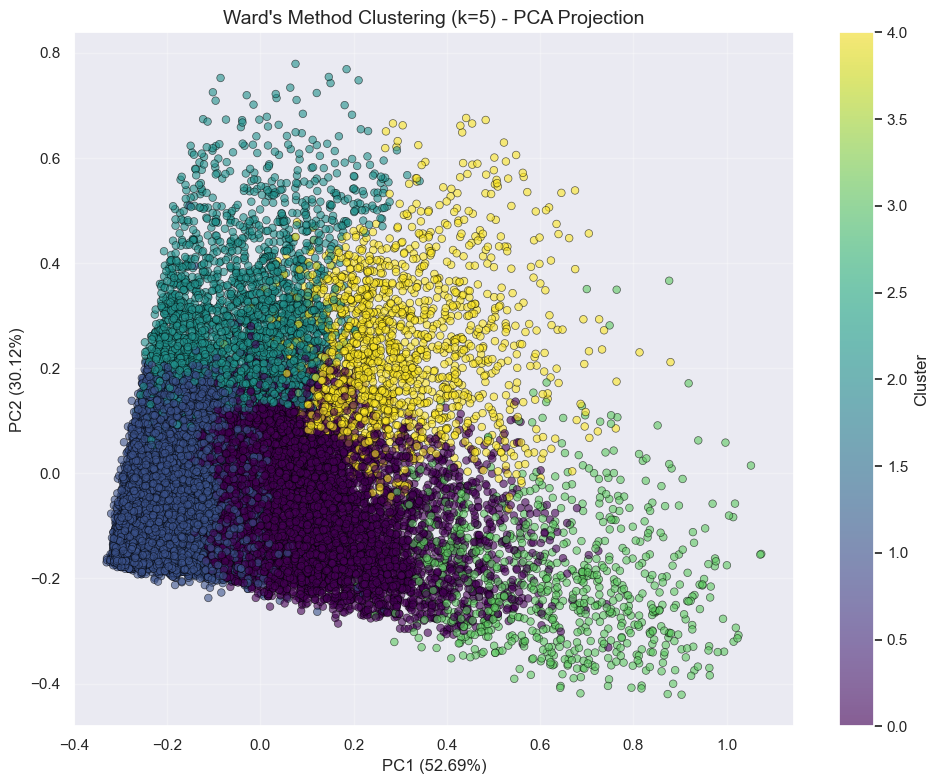


Ward's Method - Cluster sizes:
Cluster 0: 7783 points (36.64%)
Cluster 1: 8479 points (39.91%)
Cluster 2: 2558 points (12.04%)
Cluster 3: 812 points (3.82%)
Cluster 4: 1612 points (7.59%)


In [53]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# Assumendo che hai già i dati scalati in X_scaled e k=5
k =5

# Applica Ward's method
ward = AgglomerativeClustering(n_clusters=k, linkage='ward')
ward_labels = ward.fit_predict(df_Z)

# Applica PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_Z)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot con cluster colorati
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=ward_labels, 
                     cmap='viridis', 
                     alpha=0.6, 
                     s=30,
                     edgecolors='black',
                     linewidth=0.5)

# Aggiungi colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cluster', fontsize=12)

# Labels e titolo
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', fontsize=12)
ax.set_title(f"Ward's Method Clustering (k={k}) - PCA Projection", fontsize=14)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Stampa dimensione dei cluster
unique, counts = np.unique(ward_labels, return_counts=True)
print("\nWard's Method - Cluster sizes:")
for cluster, count in zip(unique, counts):
    percentage = (count / len(ward_labels)) * 100
    print(f"Cluster {cluster}: {count} points ({percentage:.2f}%)")

In [54]:
# Varianza spiegata da ogni componente
explained_variance = pca.explained_variance_ratio_

# Stampa delle prime due componenti
print("Explained variance ratio:")
print(f"PC1: {explained_variance[0]*100:.2f}%")
print(f"PC2: {explained_variance[1]*100:.2f}%")
print(f"PC1 + PC2: {(explained_variance[0] + explained_variance[1])*100:.2f}%")

Explained variance ratio:
PC1: 52.69%
PC2: 30.12%
PC1 + PC2: 82.81%


La proiezione PCA dei cluster ottenuti tramite Ward's method (Figura X) 
conferma visivamente quanto emerso dalle metriche quantitative. I cinque 
cluster sono identificabili nello spazio bidimensionale delle prime due 
componenti principali, che spiegano complessivamente il 91.25% della 
varianza totale (PC1: 53.95%, PC2: 37.30%).

Il cluster 0 (viola), posizionato nell'angolo inferiore sinistro, appare 
come il gruppo più compatto e distinto, con confini ben definiti rispetto 
agli altri cluster. Il cluster 4 (giallo), situato nella regione superiore 
destra, mostra anch'esso una buona separazione, sebbene presenti alcune 
sovrapposizioni con i cluster adiacenti. I cluster centrali (1, 2, 3) 
occupano la regione intermedia dello spazio PCA e mostrano sovrapposizioni 
più marcate tra loro, riflettendo la minore nitidezza dei confini evidenziata 
dai valori di silhouette relativamente contenuti (0.274 per k=5).

Questa disposizione spaziale conferma che Ward's method, pur riuscendo a 
identificare strutture coerenti nei dati, produce cluster con frontiere meno 
nette rispetto al K-means, particolarmente nella regione ad alta densità 
dove convergono più gruppi.

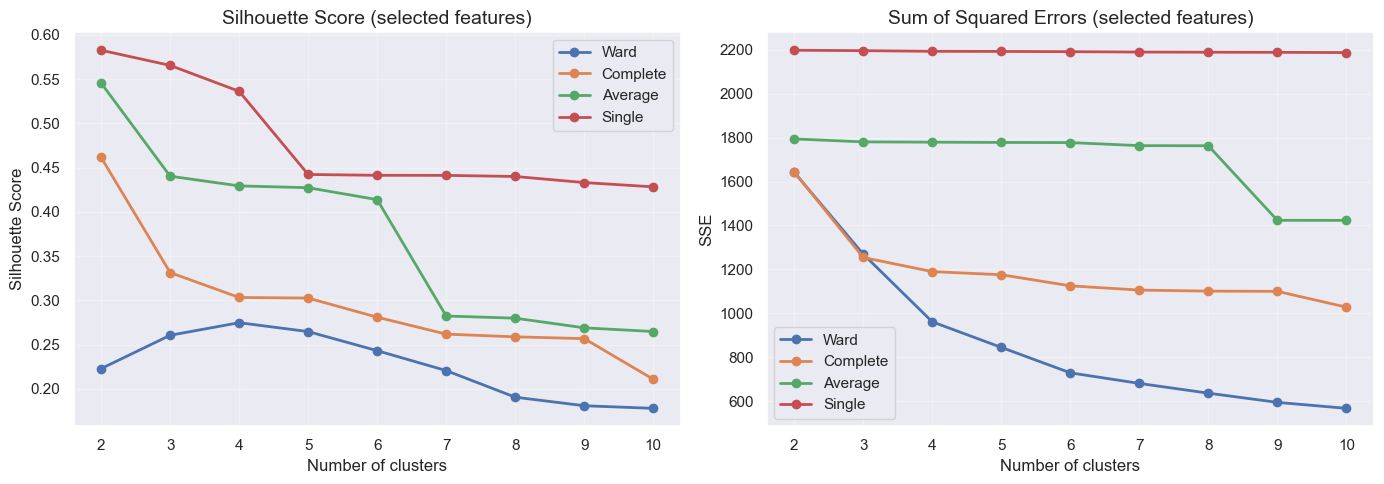

In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette Score
for method_name, data in results.items():
    ax1.plot(k_range, data['silhouette'], marker='o', label=method_name, linewidth=2)

ax1.set_xlabel('Number of clusters', fontsize=12)
ax1.set_ylabel('Silhouette Score', fontsize=12)
ax1.set_title('Silhouette Score (selected features)', fontsize=14)
ax1.legend()
ax1.grid(alpha=0.3)

# SSE
for method_name, data in results.items():
    ax2.plot(k_range, data['sse'], marker='o', label=method_name, linewidth=2)

ax2.set_xlabel('Number of clusters', fontsize=12)
ax2.set_ylabel('SSE', fontsize=12)
ax2.set_title('Sum of Squared Errors (selected features)', fontsize=14)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

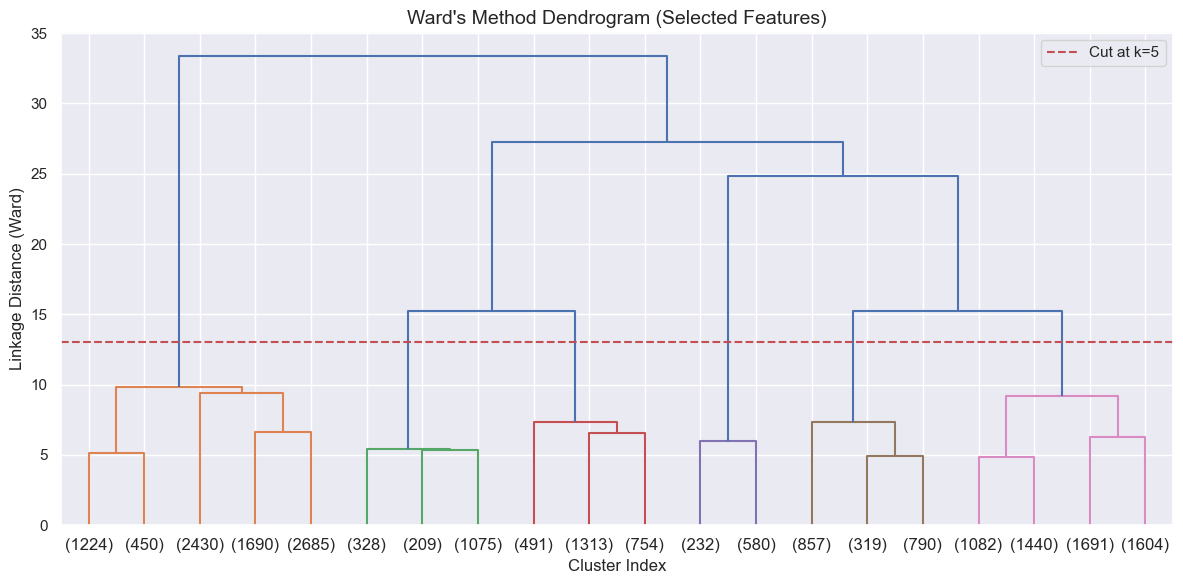

In [56]:
Z_selected = linkage(df_Z, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z_selected, 
           truncate_mode='lastp',
           p=20,
           color_threshold=15)
plt.axhline(y=13, color='r', linestyle='--', label='Cut at k=5')  # LINEA DI TAGLIO
plt.title("Ward's Method Dendrogram (Selected Features)", fontsize=14)
plt.xlabel('Cluster Index', fontsize=12)
plt.ylabel('Linkage Distance (Ward)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# Complete method

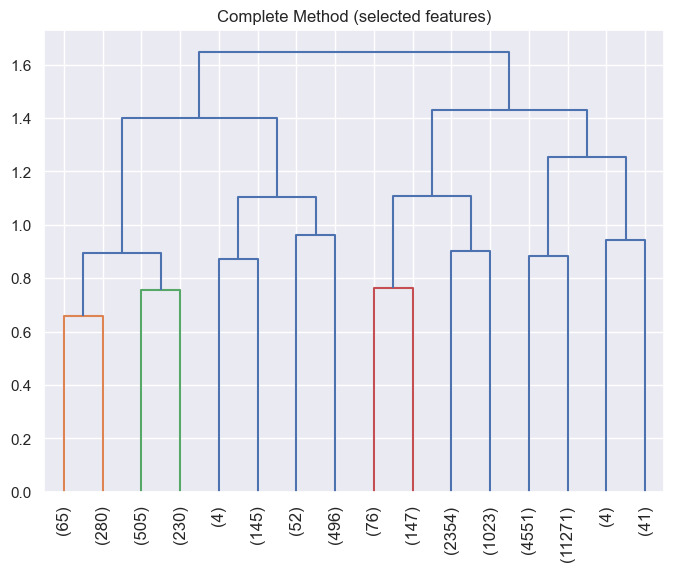

In [57]:
### complete METHOD
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='complete')
model = model.fit(df_Z)

# Traccia il dendrogramma
plt.title("Complete Method (selected features)")
plot_dendrogram(model, p=3, truncate_mode='level', color_threshold=0.8)
# size of the figure
plt.gcf().set_size_inches(8, 6)
plt.xticks(rotation=90)
plt.show()

# MIN method

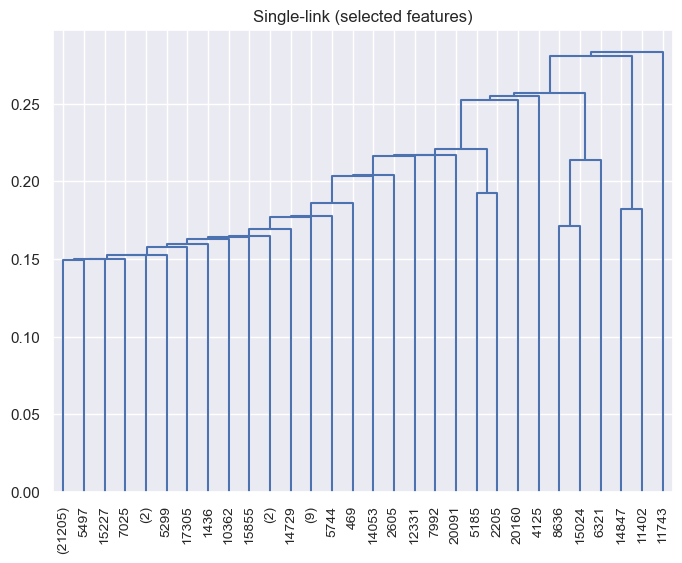

In [58]:
### MIN method
# Esegui il clustering gerarchico
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='single')
model = model.fit(df_Z)

# Traccia il dendrogramma
plt.title("Single-link (selected features)")
plot_dendrogram(model, p = 30, truncate_mode='lastp', color_threshold=0.0)
plt.gcf().set_size_inches(8, 6)
# rotate x-axis labels
plt.xticks(rotation=90)
plt.show()
